In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 60.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 44.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 65.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 45.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 35.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 48.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 53.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [seaborn]3/14 [seaborn]ib]n]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [13]:
import os
import pandas as pd
import numpy as np
import random as rd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [14]:
df = pd.read_csv('../../data/banknote_authentication.csv')

df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']
df.head()

,variance,skewness,curtosis,entropy,class
0,4.54590,8.1674,-2.4586,-1.46210,0
1,3.86600,-2.6383,1.9242,0.10645,0
2,3.45660,9.5228,-4.0112,-3.59440,0
3,0.32924,-4.4552,4.5718,-0.98880,0
4,4.36840,9.6718,-3.9606,-3.16250,0


In [15]:
X = df.drop('class', axis=1)
y = df['class']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)


In [16]:
scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=X.columns)
x_test = pd.DataFrame(scaler.transform(x_test), columns=X.columns)

In [17]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print("Class weights:", class_weights_dict)

Class weights: {np.int64(0): np.float64(0.9), np.int64(1): np.float64(1.125)}


#  FEATURE SELECTION (GIẢ LẬP) 

In [18]:
feature_selection = {
    'LR': X.columns.tolist(),
    'DTC': X.columns.tolist(),
    'NB': X.columns.tolist(),
    'KNC': X.columns.tolist(),
    'SVM': X.columns.tolist(),
    'NN': X.columns.tolist(),
    'RD': X.columns.tolist(),
    'BG': X.columns.tolist()
}

In [19]:
def check_model(name, model, X, Y, names, results, scoring):
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X[feature_selection[name]], Y, cv=kfold, scoring=scoring)
    
    results.append(cv_results)
    names.append(name)
    
    print(f"{scoring.upper()} {name}: {cv_results.mean()*100:.3f}% ({cv_results.std()*100:.3f}%)")

# TRAIN MULTI MODEL

ACCURACY LR: 98.040% (0.553%)
ACCURACY DTC: 98.912% (0.769%)
ACCURACY NB: 83.877% (1.139%)
ACCURACY KNC: 99.239% (0.737%)
ACCURACY SVM: 99.783% (0.266%)
ACCURACY NN: 99.891% (0.219%)
ACCURACY RD: 99.238% (0.265%)
ACCURACY BG: 99.130% (0.554%)


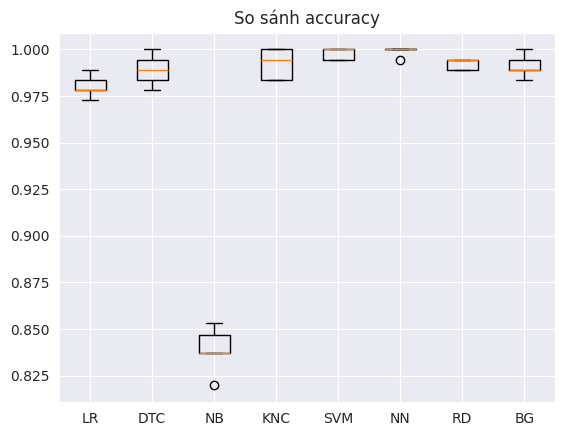

PRECISION LR: 96.210% (1.337%)
PRECISION DTC: 98.754% (1.337%)
PRECISION NB: 84.584% (4.318%)
PRECISION KNC: 98.336% (1.604%)
PRECISION SVM: 99.483% (0.634%)
PRECISION NN: 99.756% (0.488%)
PRECISION RD: 98.795% (0.749%)
PRECISION BG: 98.513% (0.983%)


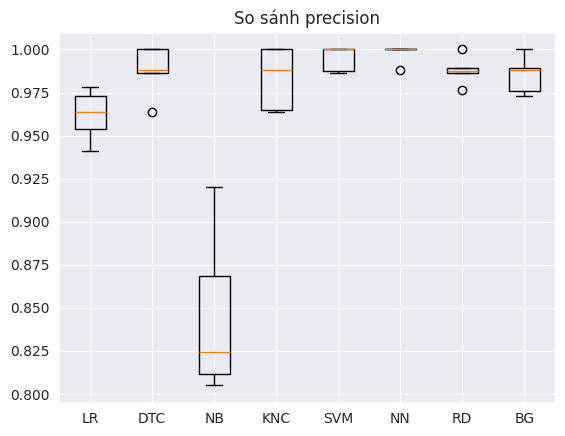

RECALL LR: 99.479% (0.639%)
RECALL DTC: 99.048% (0.900%)
RECALL NB: 77.973% (2.690%)
RECALL KNC: 100.000% (0.000%)
RECALL SVM: 100.000% (0.000%)
RECALL NN: 100.000% (0.000%)
RECALL RD: 100.000% (0.000%)
RECALL BG: 99.485% (0.633%)


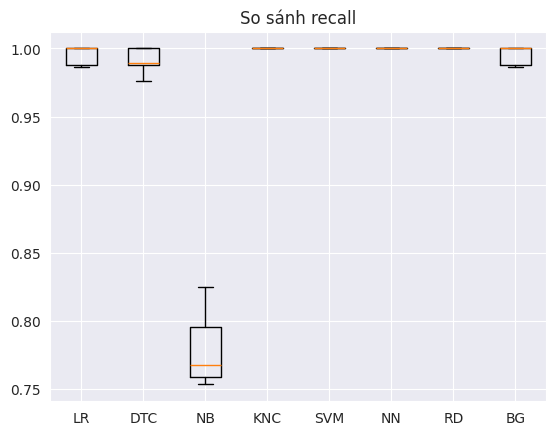

F1 LR: 97.810% (0.638%)
F1 DTC: 98.896% (0.903%)
F1 NB: 81.043% (1.929%)
F1 KNC: 99.154% (0.817%)
F1 SVM: 99.740% (0.319%)
F1 NN: 100.000% (0.000%)
F1 RD: 99.255% (0.488%)
F1 BG: 98.995% (0.691%)


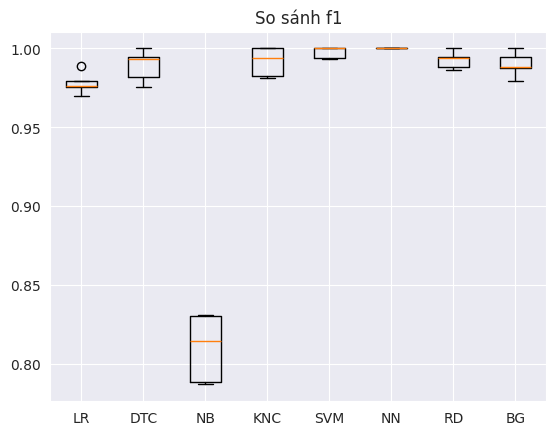

In [20]:
models = [
    ('LR', LogisticRegression(class_weight=class_weights_dict)),
    ('DTC', DecisionTreeClassifier(class_weight=class_weights_dict)),
    ('NB', GaussianNB()),
    ('KNC', KNeighborsClassifier(n_neighbors=10)),
    ('SVM', SVC(class_weight=class_weights_dict)),
    ('NN', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)),
    ('RD', RandomForestClassifier(n_estimators=100, class_weight=class_weights_dict)),
    ('BG', GradientBoostingClassifier())
]

scorings = ['accuracy', 'precision', 'recall', 'f1']

for scoring in scorings:
    results = []
    names = []
    
    for name, model in models:
        check_model(name, model, x_train, y_train, names, results, scoring)
    
    # plot
    plt.figure()
    plt.title(f"So sánh {scoring}")
    plt.boxplot(results)
    plt.xticks(range(1, len(names)+1), names)
    plt.show()


In [21]:
model = LogisticRegression(class_weight=class_weights_dict)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*","{np.int64(0): np.float64(0.9), np.int64(1): np.float64(1.125)}"
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works r

In [22]:
predictions = model.predict(x_test)

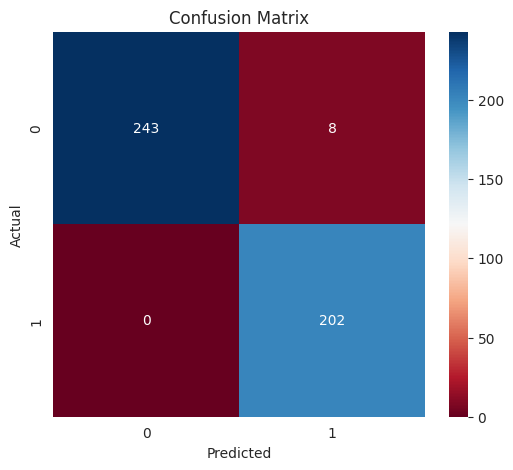

In [23]:
conf_matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="RdBu")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       251
           1       0.96      1.00      0.98       202

    accuracy                           0.98       453
   macro avg       0.98      0.98      0.98       453
weighted avg       0.98      0.98      0.98       453



In [28]:
def check_result(pred):
    return "Y" if pred == 1 else "N"

def check_output(stt, model, X_test, Y_test):
    print(f"Lần {stt}:")
    idx = rd.randint(0, len(X_test)-1)
    
    sample = X_test.iloc[idx:idx+1]
    pred = model.predict(sample)[0]
    
    true = Y_test.iloc[idx]
    
    print("True:", check_result(true))
    print("Pred:", check_result(pred))
    print("--------------------")
    
    return true == pred

# test 10 lần
correct = 0
for i in range(10):
    if check_output(i+1, model, x_test, y_test):
        correct += 1

print("Accuracy random:", correct/10 * 100, "%")

Lần 1:
True: Y
Pred: Y
--------------------
Lần 2:
True: Y
Pred: Y
--------------------
Lần 3:
True: Y
Pred: Y
--------------------
Lần 4:
True: Y
Pred: Y
--------------------
Lần 5:
True: N
Pred: N
--------------------
Lần 6:
True: N
Pred: N
--------------------
Lần 7:
True: N
Pred: N
--------------------
Lần 8:
True: N
Pred: N
--------------------
Lần 9:
True: N
Pred: N
--------------------
Lần 10:
True: N
Pred: N
--------------------
Accuracy random: 100.0 %


In [27]:
correct = 0

for i in range(len(x_test)):
    sample = x_test.iloc[i:i+1]
    pred = model.predict(sample)[0]
    
    if pred == y_test.iloc[i]:
        correct += 1

print(f"Accuracy test full: {correct/len(x_test)*100:.2f}%")

Accuracy test full: 98.23%
